# Sales Prediction Using Python
## Regression Model: Predicting Sales from Advertising Spend

**Objective:** Build regression models that predict product sales based on advertising spend across TV, Radio, and Newspaper channels.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn

**Dataset:** Advertising.csv (Kaggle)

---

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("done !")

done !


In [2]:

import os

df = None
loaded_file = None

possible_files = ['Advertising.csv', 'advertising.csv', 'Advertising_Data.csv']

for fname in possible_files:
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        loaded_file = fname
        print(f"Loaded from local file: {fname}")
        break

if df is None:
    try:
        url = 'https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv'
        df = pd.read_csv(url)
        loaded_file = url
        print(f" Downloaded from: {url}")
    except Exception as e:
        print(f"Could not download: {e}")
        files = [f for f in os.listdir('.') if f.endswith('.csv')]
        print(f"   CSV files in folder: {files}")
        print("   Please download Advertising.csv from Kaggle and place it here.")

if df is not None:
    print(f"\nDataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumns: {df.columns.tolist()}")
    print("\nFirst 5 rows:")
    display(df.head())

Loaded from local file: Advertising.csv

Dataset shape: 200 rows × 4 columns

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

First 5 rows:


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:

df.columns = df.columns.str.strip().str.lower()

if 'unnamed: 0' in df.columns:
    df = df.drop('unnamed: 0', axis=1)

print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== NULL VALUES ===")
nulls = df.isnull().sum()
print(nulls)
print(f"\nTotal nulls: {nulls.sum()}")
if nulls.sum() == 0:
    print(" No missing values!")

print(f"\n=== DUPLICATE ROWS ===")
print(f"Duplicates: {df.duplicated().sum()}")

print("\n=== DESCRIPTIVE STATISTICS ===")
print(df.describe().round(2))

=== DATA TYPES ===
tv           float64
radio        float64
newspaper    float64
sales        float64
dtype: object

=== NULL VALUES ===
tv           0
radio        0
newspaper    0
sales        0
dtype: int64

Total nulls: 0
 No missing values!

=== DUPLICATE ROWS ===
Duplicates: 0

=== DESCRIPTIVE STATISTICS ===
           tv   radio  newspaper   sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   15.13
std     85.85   14.85      21.78    5.28
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   11.00
50%    149.75   22.90      25.75   16.00
75%    218.82   36.52      45.10   19.05
max    296.40   49.60     114.00   27.00


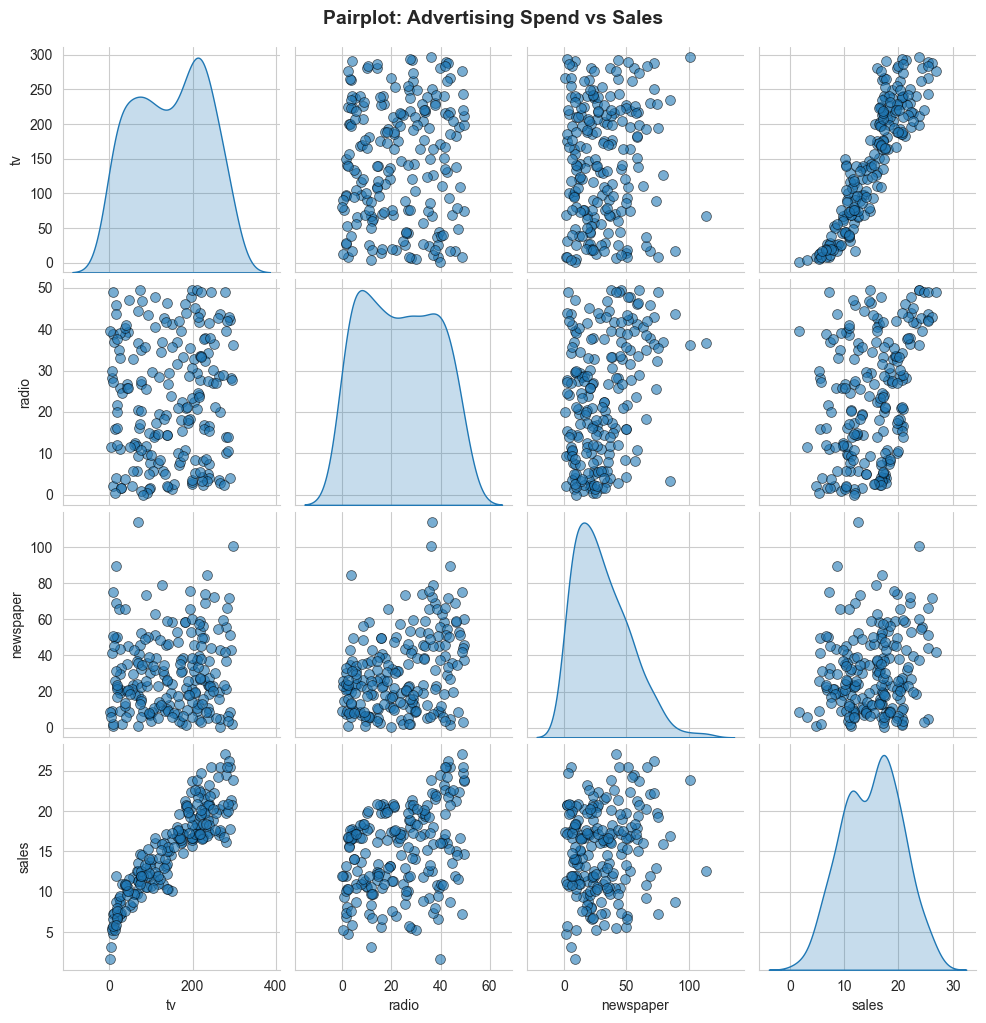

In [4]:

pairplot = sns.pairplot(
    df,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 50, 'edgecolor': 'black'},
    diag_kws={'fill': True},
    height=2.5
)
pairplot.fig.suptitle('Pairplot: Advertising Spend vs Sales', y=1.02, fontsize=14, fontweight='bold')
plt.show()

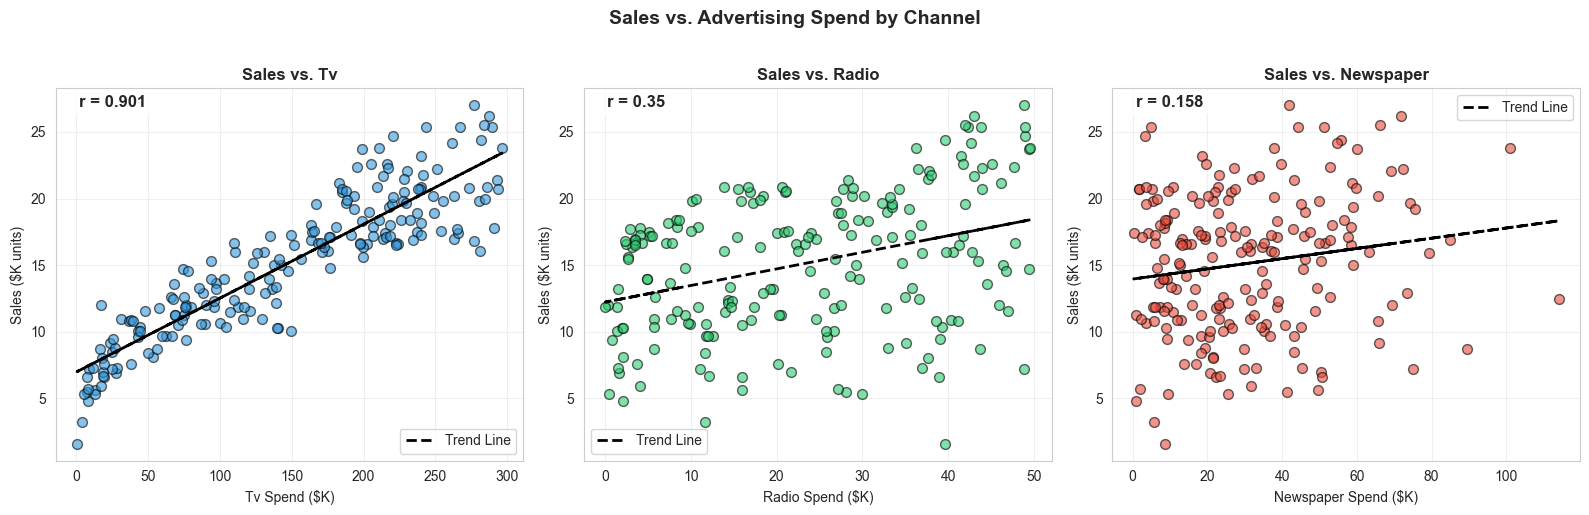

 Observations:
   Tv: correlation = 0.901
   Radio: correlation = 0.350
   Newspaper: correlation = 0.158


In [5]:

features = ['tv', 'radio', 'newspaper']
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (feature, color) in enumerate(zip(features, colors)):
    axes[idx].scatter(df[feature], df['sales'],
                     alpha=0.6, color=color, edgecolors='black', s=50)

    z = np.polyfit(df[feature], df['sales'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "k--", linewidth=2, label='Trend Line')
    
    axes[idx].set_xlabel(f'{feature.capitalize()} Spend ($K)')
    axes[idx].set_ylabel('Sales ($K units)')
    axes[idx].set_title(f'Sales vs. {feature.capitalize()}', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

    corr = df[feature].corr(df['sales']).round(3)
    axes[idx].text(0.05, 0.95, f'r = {corr}', transform=axes[idx].transAxes,
                  fontsize=12, fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Sales vs. Advertising Spend by Channel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" Observations:")
for feature in features:
    corr = df[feature].corr(df['sales'])
    print(f"   {feature.capitalize()}: correlation = {corr:.3f}")

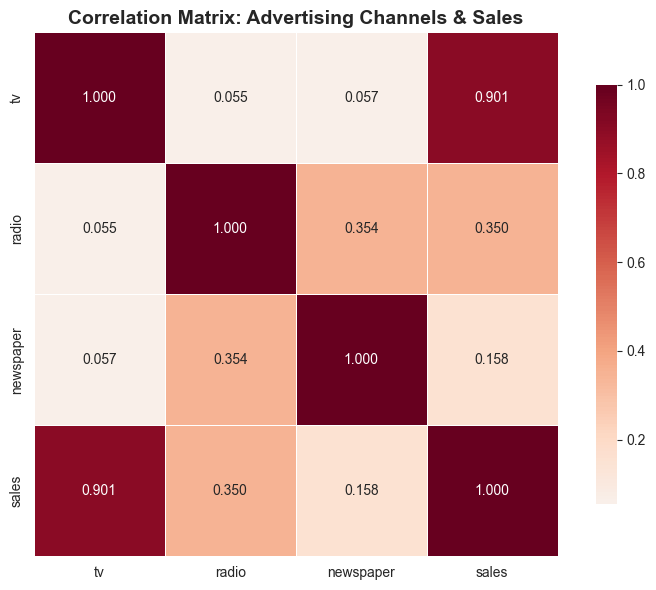

=== CORRELATIONS WITH SALES ===
  • Tv: 0.901
  • Radio: 0.350
  • Newspaper: 0.158


In [6]:

corr_matrix = df.corr().round(3)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.3f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix: Advertising Channels & Sales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

sales_corr = corr_matrix['sales'].drop('sales').sort_values(ascending=False)
print("=== CORRELATIONS WITH SALES ===")
for channel, corr in sales_corr.items():
    print(f"  • {channel.capitalize()}: {corr:.3f}")



In [7]:

X = df[['tv', 'radio', 'newspaper']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features:     {X_train.shape[1]} (TV, Radio, Newspaper)")

print(f"\nTraining stats — Sales mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"Test stats     — Sales mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Training set: 160 samples (80%)
Test set:     40 samples (20%)
Features:     3 (TV, Radio, Newspaper)

Training stats — Sales mean: 15.33, std: 5.19
Test stats     — Sales mean: 14.33, std: 5.63


In [8]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== LINEAR REGRESSION RESULTS ===")
print(f"MAE:  {mae_lr:.3f} ($K)")
print(f"RMSE: {rmse_lr:.3f} ($K)")
print(f"R²:   {r2_lr:.4f}")

print("\n=== COEFFICIENTS (Impact per $1K spent) ===")
for feature, coef in zip(X.columns, lr.coef_):
    print(f"  {feature.capitalize():10s}: {coef:+.4f}  → For every $1K spent, sales change by ${coef:.4f}K")
print(f"  {'Intercept':10s}: {lr.intercept_:.4f}")


=== LINEAR REGRESSION RESULTS ===
MAE:  1.275 ($K)
RMSE: 1.705 ($K)
R²:   0.9059

=== COEFFICIENTS (Impact per $1K spent) ===
  Tv        : +0.0545  → For every $1K spent, sales change by $0.0545K
  Radio     : +0.1009  → For every $1K spent, sales change by $0.1009K
  Newspaper : +0.0043  → For every $1K spent, sales change by $0.0043K
  Intercept : 4.7141


In [9]:

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== RANDOM FOREST RESULTS ===")
print(f"MAE:  {mae_rf:.3f} ($K)")
print(f"RMSE: {rmse_rf:.3f} ($K)")
print(f"R²:   {r2_rf:.4f}")

importances = rf.feature_importances_
print("\n=== FEATURE IMPORTANCE ===")
for feature, imp in zip(X.columns, importances):
    print(f"  {feature.capitalize():10s}: {imp:.4f} ({imp*100:.1f}%)")


=== RANDOM FOREST RESULTS ===
MAE:  0.918 ($K)
RMSE: 1.199 ($K)
R²:   0.9535

=== FEATURE IMPORTANCE ===
  Tv        : 0.8454 (84.5%)
  Radio     : 0.1366 (13.7%)
  Newspaper : 0.0180 (1.8%)


In [10]:

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]} (includes squares and interactions)")

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

poly_lr = LinearRegression()
poly_lr.fit(X_train_poly_scaled, y_train)

y_pred_poly = poly_lr.predict(X_test_poly_scaled)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("\n=== POLYNOMIAL REGRESSION RESULTS ===")
print(f"MAE:  {mae_poly:.3f} ($K)")
print(f"RMSE: {rmse_poly:.3f} ($K)")
print(f"R²:   {r2_poly:.4f}")

feature_names = poly.get_feature_names_out(X.columns)
print(f"\nPolynomial features include: {list(feature_names)}")


Original features: 3
Polynomial features: 9 (includes squares and interactions)

=== POLYNOMIAL REGRESSION RESULTS ===
MAE:  0.903 ($K)
RMSE: 1.201 ($K)
R²:   0.9533

Polynomial features include: ['tv', 'radio', 'newspaper', 'tv^2', 'tv radio', 'tv newspaper', 'radio^2', 'radio newspaper', 'newspaper^2']


=== MODEL COMPARISON ===
                        Model    MAE   RMSE     R²
                Random Forest 0.9180 1.1989 0.9535
Polynomial Regression (deg 2) 0.9034 1.2011 0.9533
            Linear Regression 1.2748 1.7052 0.9059


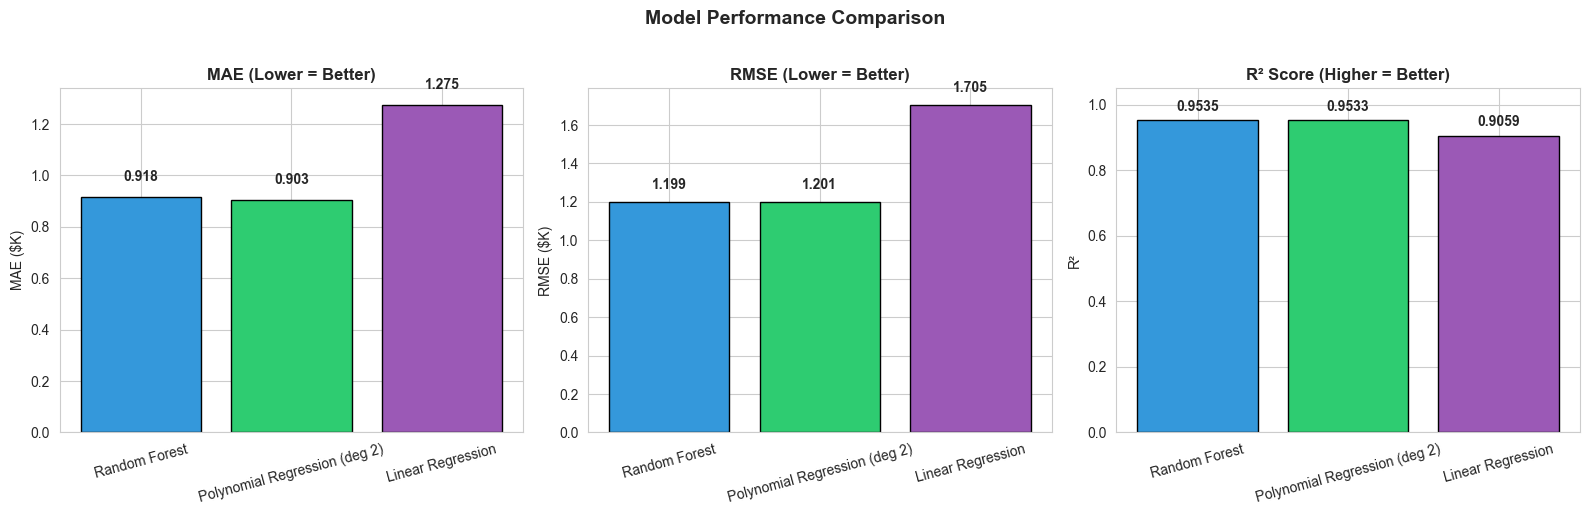


 BEST MODEL: Random Forest


In [11]:

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Polynomial Regression (deg 2)'],
    'MAE': [mae_lr, mae_rf, mae_poly],
    'RMSE': [rmse_lr, rmse_rf, rmse_poly],
    'R²': [r2_lr, r2_rf, r2_poly]
})

comparison = comparison.sort_values('R²', ascending=False)

print("=== MODEL COMPARISON ===")
print(comparison.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#3498db', '#2ecc71', '#9b59b6']

bars1 = axes[0].bar(comparison['Model'], comparison['MAE'], color=colors, edgecolor='black')
axes[0].set_title('MAE (Lower = Better)', fontweight='bold')
axes[0].set_ylabel('MAE ($K)')
for bar, val in zip(bars1, comparison['MAE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(comparison['Model'], comparison['RMSE'], color=colors, edgecolor='black')
axes[1].set_title('RMSE (Lower = Better)', fontweight='bold')
axes[1].set_ylabel('RMSE ($K)')
for bar, val in zip(bars2, comparison['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

bars3 = axes[2].bar(comparison['Model'], comparison['R²'], color=colors, edgecolor='black')
axes[2].set_title('R² Score (Higher = Better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1.05)
for bar, val in zip(bars3, comparison['R²']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
              f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_model_name = comparison.iloc[0]['Model']
print(f"\n BEST MODEL: {best_model_name}")

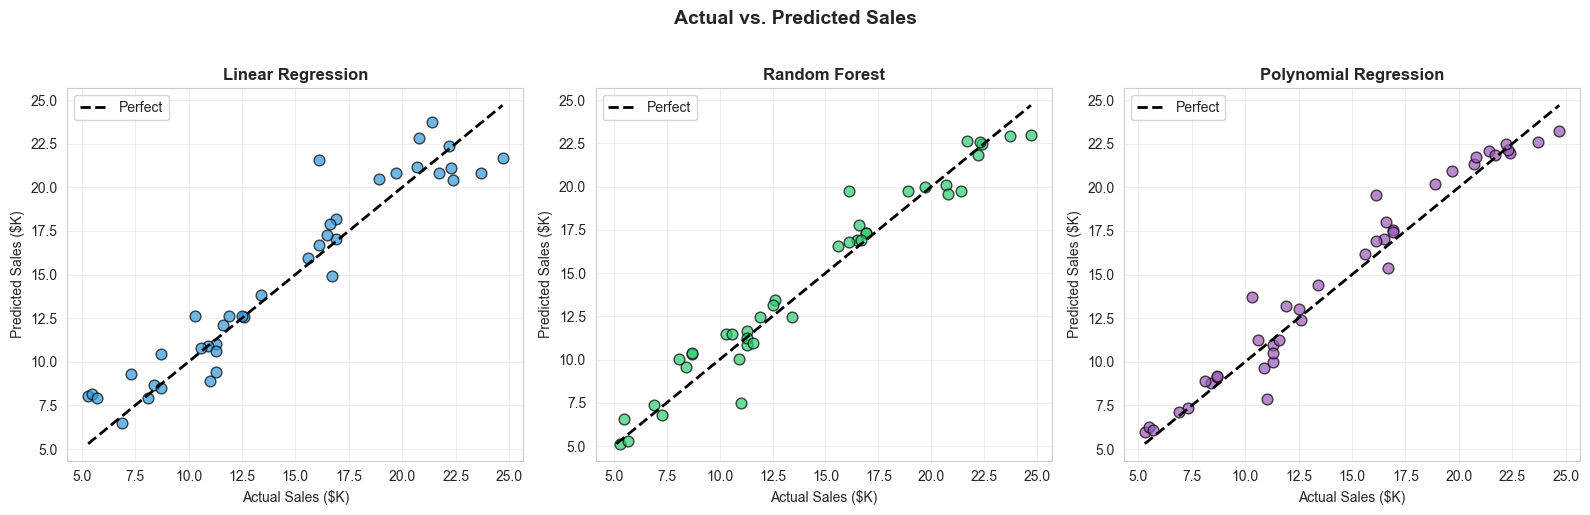

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

predictions = {
    'Linear Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Polynomial Regression': y_pred_poly
}

for idx, (name, y_pred) in enumerate(predictions.items()):
    axes[idx].scatter(y_test, y_pred, alpha=0.7, color=colors[idx], edgecolors='black', s=60)
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect')
    
    axes[idx].set_xlabel('Actual Sales ($K)')
    axes[idx].set_ylabel('Predicted Sales ($K)')
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Actual vs. Predicted Sales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


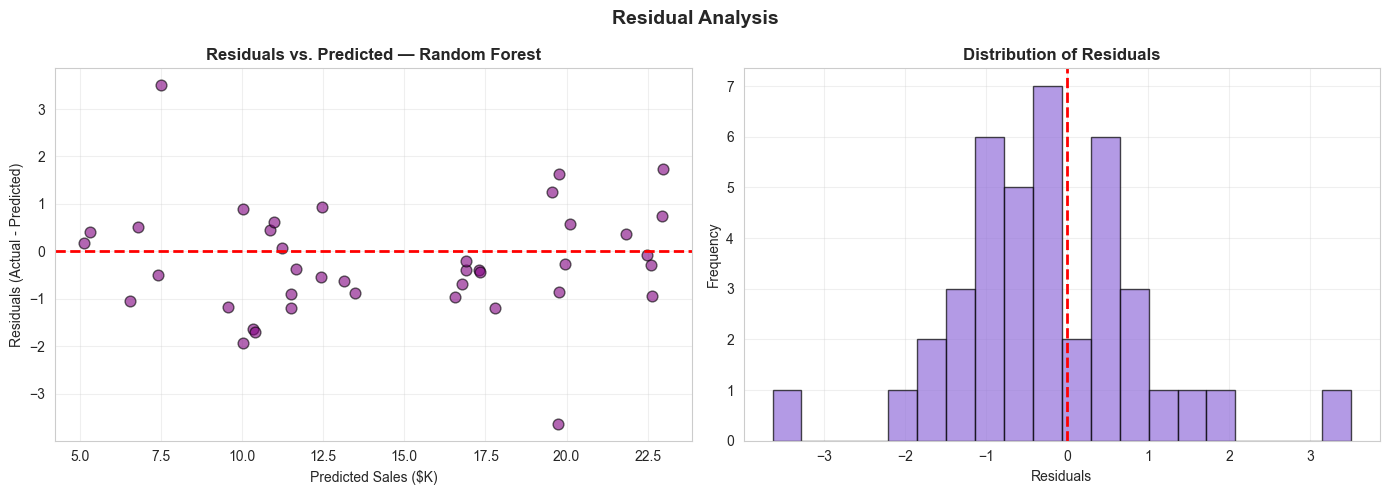

=== RESIDUAL STATISTICS (Random Forest) ===
Mean residual: -0.2250 (should be ~0)
Std residual:  1.1926
Min residual:  -3.6360
Max residual:  3.5010

Correlation (predicted vs residuals): 0.0083
 Residuals appear randomly distributed good model fit!


In [13]:

best_predictions = {
    'Linear Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Polynomial Regression (deg 2)': y_pred_poly
}[best_model_name]

residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_predictions, residuals, alpha=0.6,
               color='purple', edgecolors='black', s=60)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Sales ($K)')
axes[0].set_ylabel('Residuals (Actual - Predicted)')
axes[0].set_title(f'Residuals vs. Predicted — {best_model_name}', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=20, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"=== RESIDUAL STATISTICS ({best_model_name}) ===")
print(f"Mean residual: {residuals.mean():.4f} (should be ~0)")
print(f"Std residual:  {residuals.std():.4f}")
print(f"Min residual:  {residuals.min():.4f}")
print(f"Max residual:  {residuals.max():.4f}")

resid_corr = np.corrcoef(best_predictions, residuals)[0, 1]
print(f"\nCorrelation (predicted vs residuals): {resid_corr:.4f}")

if abs(resid_corr) < 0.1:
    print(" Residuals appear randomly distributed good model fit!")
else:
    print("  Residuals show correlation with predictions — model may be missing patterns.")


=== CHANNEL IMPACT ANALYSIS ===

METHOD 1: Linear Regression Coefficients
(Direct interpretation: sales change per $1K spent)

  Channel  Coefficient  Impact_per_1K
    Radio     0.100945       0.100945
       TV     0.054509       0.054509
Newspaper     0.004337       0.004337

METHOD 2: Random Forest Feature Importance
(Relative contribution to prediction accuracy)

  Channel  Importance  Pct_Importance
       TV    0.845355       84.535495
    Radio    0.136642       13.664184
Newspaper    0.018003        1.800321

METHOD 3: Correlation with Sales
(Simple linear relationship strength)

  Channel  Correlation_with_Sales
       TV                0.901208
    Radio                0.349631
Newspaper                0.157960


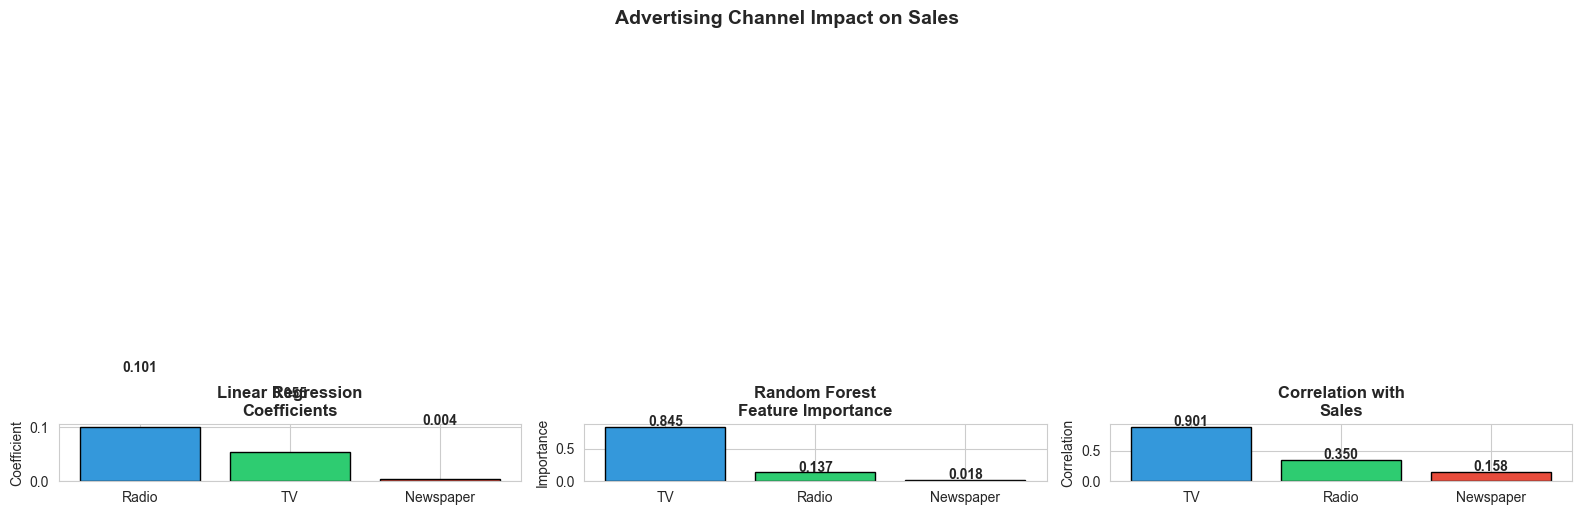


=== CONCLUSION ===
   TV is the most impactful channel across ALL three methods.
   Radio is the second most impactful.
   Newspaper has the weakest impact on sales.


In [14]:

print("=== CHANNEL IMPACT ANALYSIS ===\n")

print("METHOD 1: Linear Regression Coefficients")
print("(Direct interpretation: sales change per $1K spent)" + "\n")
lr_coefs = pd.DataFrame({
    'Channel': ['TV', 'Radio', 'Newspaper'],
    'Coefficient': lr.coef_,
    'Impact_per_1K': lr.coef_
}).sort_values('Coefficient', ascending=False)
print(lr_coefs.to_string(index=False))

print("\nMETHOD 2: Random Forest Feature Importance")
print("(Relative contribution to prediction accuracy)" + "\n")
rf_imp = pd.DataFrame({
    'Channel': ['TV', 'Radio', 'Newspaper'],
    'Importance': rf.feature_importances_,
    'Pct_Importance': rf.feature_importances_ * 100
}).sort_values('Importance', ascending=False)
print(rf_imp.to_string(index=False))

print("\nMETHOD 3: Correlation with Sales")
print("(Simple linear relationship strength)" + "\n")
corrs = pd.DataFrame({
    'Channel': ['TV', 'Radio', 'Newspaper'],
    'Correlation_with_Sales': [df['tv'].corr(df['sales']),
                               df['radio'].corr(df['sales']),
                               df['newspaper'].corr(df['sales'])]
}).sort_values('Correlation_with_Sales', ascending=False)
print(corrs.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(lr_coefs['Channel'], lr_coefs['Coefficient'], color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Linear Regression\nCoefficients', fontweight='bold')
axes[0].set_ylabel('Coefficient')
for i, v in enumerate(lr_coefs['Coefficient']):
    axes[0].text(i, v + 0.1, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(rf_imp['Channel'], rf_imp['Importance'], color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Random Forest\nFeature Importance', fontweight='bold')
axes[1].set_ylabel('Importance')
for i, v in enumerate(rf_imp['Importance']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[2].bar(corrs['Channel'], corrs['Correlation_with_Sales'], color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
axes[2].set_title('Correlation with\nSales', fontweight='bold')
axes[2].set_ylabel('Correlation')
for i, v in enumerate(corrs['Correlation_with_Sales']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Advertising Channel Impact on Sales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n=== CONCLUSION ===")
print(f"   TV is the most impactful channel across ALL three methods.")
print(f"   Radio is the second most impactful.")
print(f"   Newspaper has the weakest impact on sales.")

In [15]:

best_model = {
    'Linear Regression': lr,
    'Random Forest': rf,
    'Polynomial Regression (deg 2)': poly_lr
}[best_model_name]

new_budgets = pd.DataFrame({
    'tv': [150, 50, 200, 30],
    'radio': [20, 40, 10, 50],
    'newspaper': [10, 30, 5, 40]
})

print(f"=== SALES PREDICTIONS ({best_model_name}) ===\n")
print(f"{'TV ($K)':>10} {'Radio ($K)':>12} {'News ($K)':>12} {'Predicted Sales':>18}")

for idx, row in new_budgets.iterrows():
    if best_model_name == 'Polynomial Regression (deg 2)':
        
        row_poly = poly.transform([row.values])
        row_poly_scaled = scaler.transform(row_poly)
        pred = best_model.predict(row_poly_scaled)[0]
    else:
        pred = best_model.predict([row.values])[0]
    
    print(f"{row['tv']:>10.0f} {row['radio']:>12.0f} {row['newspaper']:>12.0f} {pred:>18.2f}")


=== SALES PREDICTIONS (Random Forest) ===

   TV ($K)   Radio ($K)    News ($K)    Predicted Sales
       150           20           10              14.55
        50           40           30              10.93
       200           10            5              18.09
        30           50           40               9.46
